In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [199]:
df = pd.read_csv('../data/telco_churn.csv')

In [200]:
df.shape

(7043, 21)

In [201]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [202]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [203]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

The data type of totalcharges should be numeric but it is string

In [204]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [205]:
# changing the datatype of TotalCharges to numeric and checking for null values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [206]:
# filling the null values in TotalCharges with median value to keep the distribution of the data balanced
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [207]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

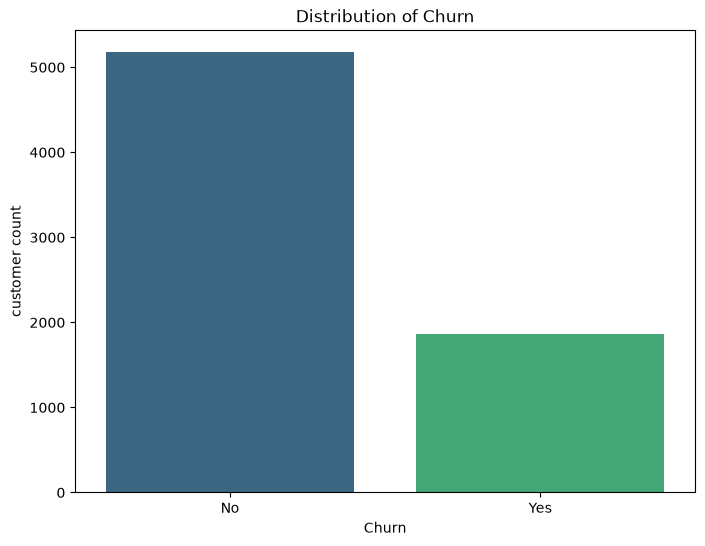

In [208]:
churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_counts.index, y=churn_counts.values,hue=churn_counts.index, palette='viridis')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('customer count')
plt.show()

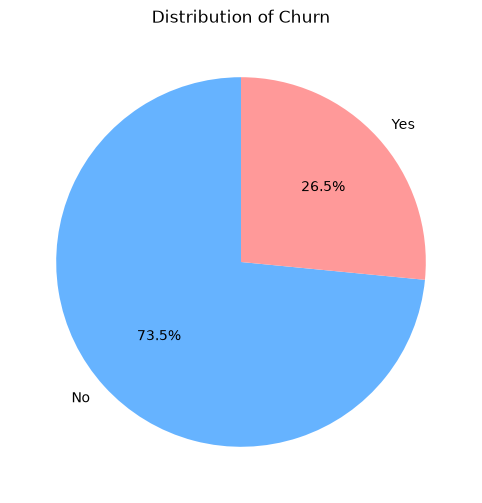

In [209]:
plt.figure(figsize=(8, 6))
plt.pie(churn_counts, labels=churn_counts.index, autopct= '%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Distribution of Churn')
plt.show()

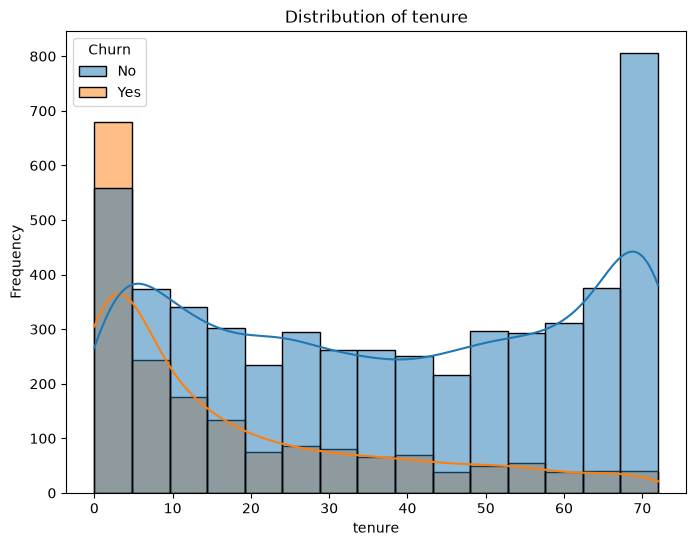

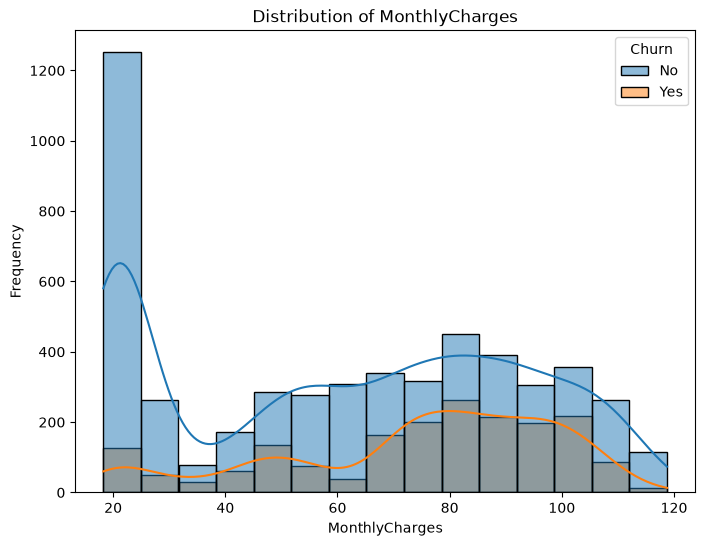

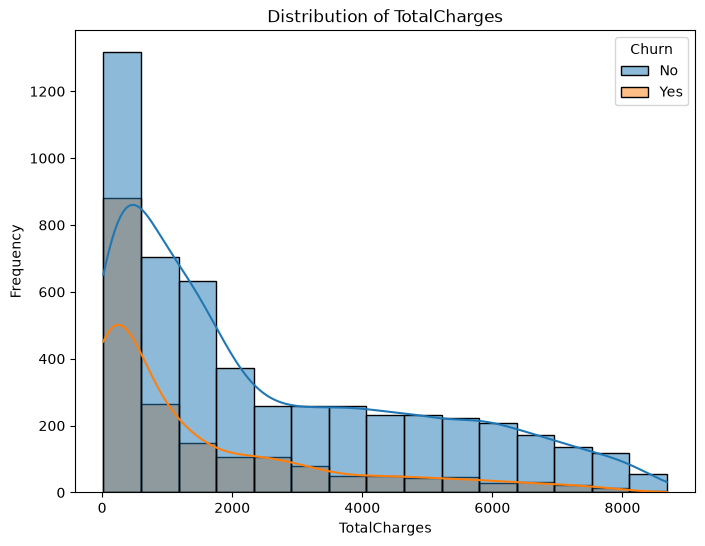

In [210]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=col, hue=df['Churn'], kde=True, bins=15)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [211]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

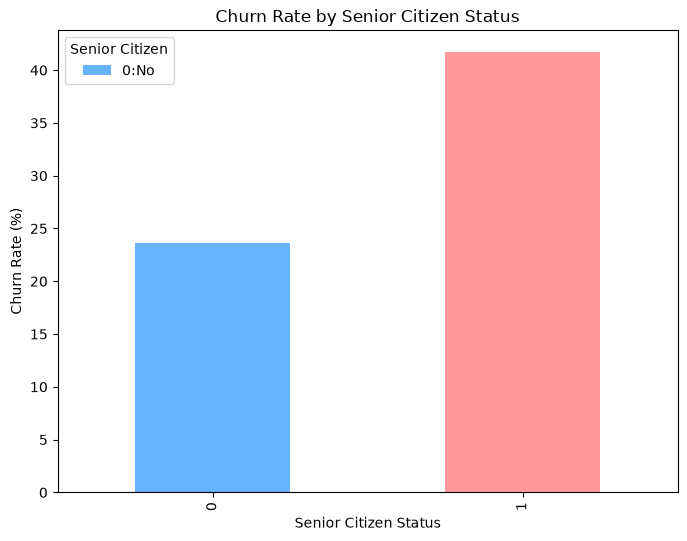

In [212]:
(df.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x=="Yes").mean()*100)).plot(kind='bar', figsize=(8, 6), color=['#66b3ff','#ff9999'])
plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Senior Citizen Status')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Senior Citizen', labels=['0:No', '1:Yes'])
plt.show()

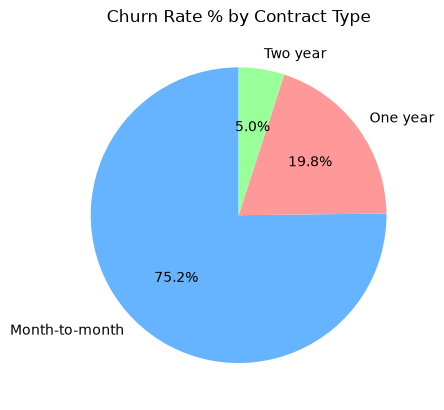

In [213]:
ct = df.groupby('Contract')['Churn'].apply(lambda x: (x == "Yes").mean()*100)
ct.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999','#99ff99'])
plt.title('Churn Rate % by Contract Type')
plt.show()

In [214]:
df1= df.copy()


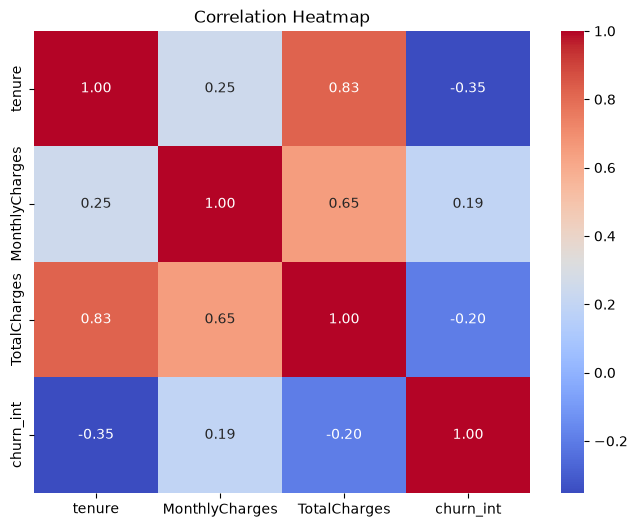

In [215]:
df1['churn_int'] = df1['Churn'].map({"Yes": 1 , "No": 0})
corr= df1[['tenure','MonthlyCharges', 'TotalCharges', 'churn_int']]
plt.figure(figsize=(8, 6))
sns.heatmap(corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [216]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [217]:
num_col= df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df[num_col].skew()

SeniorCitizen     1.833633
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963789
dtype: float64

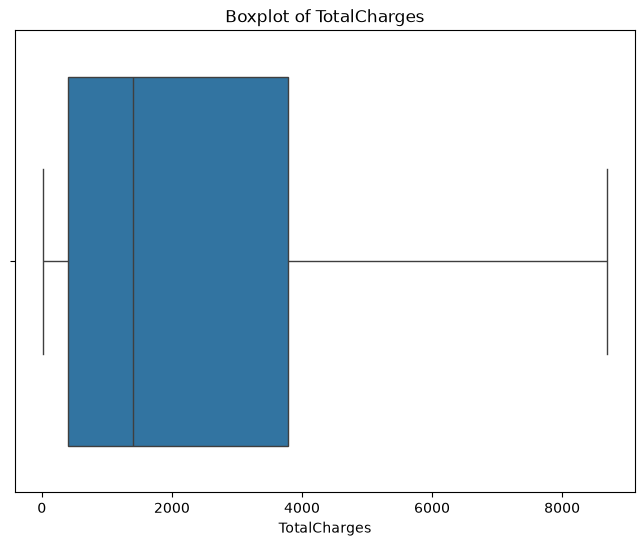

In [218]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df['TotalCharges'], orient='h')
plt.title('Boxplot of TotalCharges')
plt.show()
                    
                    

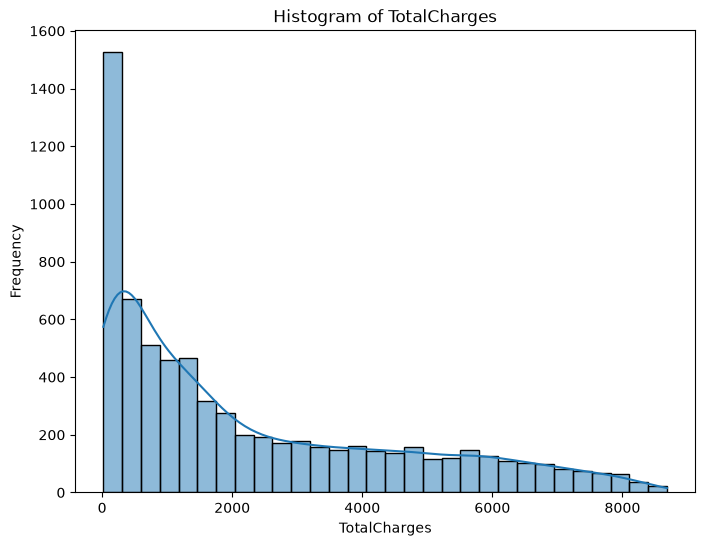

In [219]:
plt.figure(figsize=(8, 6))
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title('Histogram of TotalCharges')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.show()

In [220]:
original_skewness = df['TotalCharges'].skew()
original_skewness

np.float64(0.9637890936414893)

In [221]:
df['TotalCharges'] = np.log1p(df['TotalCharges']+1)  # Adding 1 to avoid log(0)
log_skewness = df['TotalCharges'].skew()
log_skewness

np.float64(-0.7344764091430802)

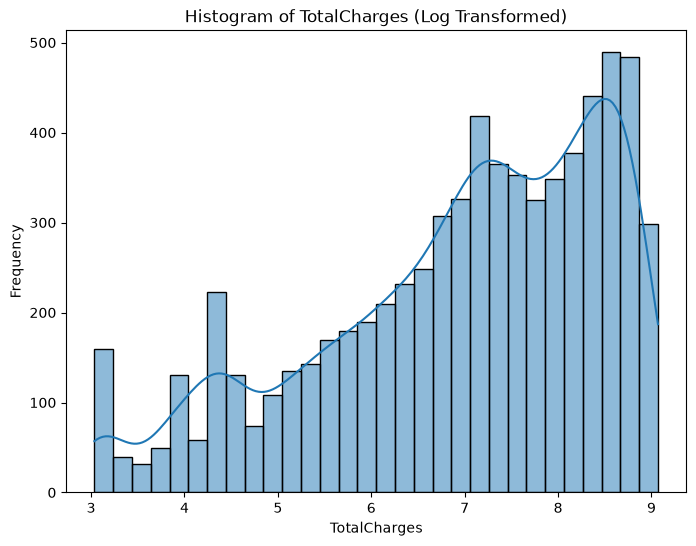

In [222]:
plt.figure(figsize=(8, 6))
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title('Histogram of TotalCharges (Log Transformed)')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.show()

## PREPROCESSING

In [223]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,3.461037,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,7.545125,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,4.701843,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,7.519014,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,5.034677,Yes


In [224]:
# converting the target variable 'Churn' to binary format for modeling
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [225]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [226]:
df.drop('customerID', axis=1, inplace=True)

In [227]:
X= df.drop('Churn', axis=1)
y= df['Churn']

In [228]:
cat_col= df.select_dtypes(include=['object', 'string']).columns.tolist()

In [229]:
num_col

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [230]:
cat_col

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [231]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder)
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
  ('num', StandardScaler(), num_col),
  ('cat', OneHotEncoder(
      handle_unknown='ignore',
      sparse_output=False), cat_col)
])

In [232]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,3.461037,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,7.545125,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,4.701843,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,7.519014,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,5.034677,1


In [234]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [235]:
print(f"Train: {X_train.shape}")  # (5634, 19)
print(f"Test:  {X_test.shape}")   # (1409, 19)
print(f"Train churn %: {y_train.mean()*100:.1f}%")
print(f"Test churn  %: {y_test.mean()*100:.1f}%")

Train: (5634, 19)
Test:  (1409, 19)
Train churn %: 26.5%
Test churn  %: 26.5%
